# 8.1 Deep Learning — TensorFlow/Keras Inference

In [1]:
import os, sys
import tensorflow as tf
os.environ["KERAS_BACKEND"]="tensorflow"
import keras
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
tf.__version__

'2.19.0'

In [2]:
!wget https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/07_DeepLearning/car.jpg

--2026-04-04 15:56:53--  https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/07_DeepLearning/car.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60742 (59K) [image/jpeg]
Saving to: ‘car.jpg’

car.jpg             100%[===================>]  59.32K  --.-KB/s    in 0.01s   

2026-04-04 15:56:53 (4.66 MB/s) - ‘car.jpg’ saved [60742/60742]



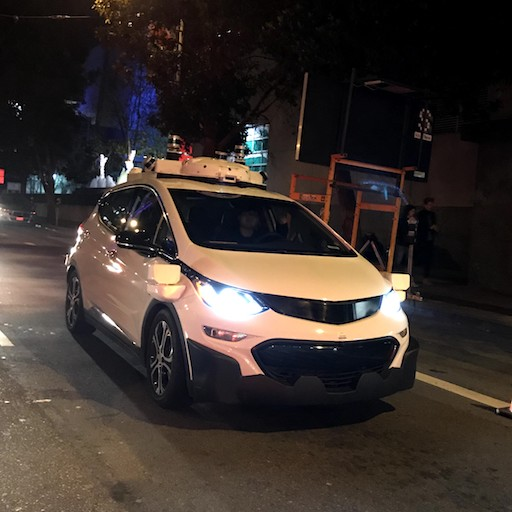

In [3]:
from IPython.display import Image
Image("car.jpg")

In [11]:

import time
# Load ResNet50 model with pretrained ImageNet weights
model_resnet = ResNet50(weights="imagenet")

# Path to image
img_path = "car.jpg"

# Load image and resize it to 224x224
img = image.load_img(img_path, target_size=(224, 224))

# Convert image to numpy array
x = image.img_to_array(img)

# Add extra dimension because model expects a batch
x = np.expand_dims(x, axis=0)

# Preprocess image for ResNet50
x = preprocess_input(x)

# Warm-up runs to avoid measuring one time setup overhead
# Warm‑ups were added once I recognized that the timing differed from run to run.
for _ in range(3):
    _ = model_resnet.predict(x, verbose=0)



#Since the timing variation still wasn’t resolved, I decided to measure ten runs and report the average to reduce the differences.
#This was part of the experimentation and learning process, and I wanted to share it to illustrate the variation.
# Run prediction
times = []

for i in range(10):
    start = time.time()
    preds = model_resnet.predict(x, verbose=0)
    end = time.time()
    times.append(end - start)
    print ("Run",i, "time =", end-start, "seconds")

# Show top 3 predicted classes
print("ResNet50 predictions:")
print(decode_predictions(preds, top=3)[0])
print("ResNet50 Inference average time :", np.mean(times), "seconds")

Run 0 time = 0.2971975803375244 seconds
Run 1 time = 0.37287116050720215 seconds
Run 2 time = 0.37016797065734863 seconds
Run 3 time = 0.2771785259246826 seconds
Run 4 time = 0.266693115234375 seconds
Run 5 time = 0.36928248405456543 seconds
Run 6 time = 0.372683048248291 seconds
Run 7 time = 0.2755153179168701 seconds
Run 8 time = 0.37483668327331543 seconds
Run 9 time = 0.2641723155975342 seconds
ResNet50 predictions:
[('n03770679', 'minivan', np.float32(0.4097556)), ('n02930766', 'cab', np.float32(0.20739873)), ('n03670208', 'limousine', np.float32(0.13904054))]
ResNet50 Inference average time : 0.3240598201751709 seconds


In [15]:
from keras.applications.vgg16 import VGG16, preprocess_input as preprocess_vgg

# Load VGG16 model
model_vgg = VGG16(weights="imagenet")

# IMPORTANT: use SAME image, but new preprocessing
x_vgg = preprocess_vgg(x.copy())
# Warm-up runs to avoid measuring one time setup overhead
#
for _ in range(3):
    _ = model_vgg.predict(x, verbose=0)
# Run prediction
for i in range(10):
    start = time.time()
    preds = model_vgg.predict(x, verbose=0)
    end = time.time()
    times.append(end - start)
    print ("Run",i, "time =", end-start, "seconds")

# Show results
print("VGG16 predictions:")
print(decode_predictions(preds_vgg, top=3)[0])
print("VGG16 Inference time:", np.mean(times), "seconds")

Run 0 time = 0.6950604915618896 seconds
Run 1 time = 1.096480369567871 seconds
Run 2 time = 1.0982418060302734 seconds
Run 3 time = 1.0069873332977295 seconds
Run 4 time = 0.6238951683044434 seconds
Run 5 time = 1.4748709201812744 seconds
Run 6 time = 0.6378374099731445 seconds
Run 7 time = 0.7217729091644287 seconds
Run 8 time = 0.7153794765472412 seconds
Run 9 time = 0.7081573009490967 seconds
VGG16 predictions:
[('n03770679', 'minivan', np.float32(0.87375337)), ('n03670208', 'limousine', np.float32(0.043620225)), ('n02930766', 'cab', np.float32(0.020925919))]
VGG16 Inference time: 0.6009640693664551 seconds


In [1]:
# Download a new test image
!wget https://commons.wikimedia.org/wiki/File:Sleeping_cat_on_her_back.jpg -O cat.jpg

--2026-04-04 16:39:16--  https://commons.wikimedia.org/wiki/File:Sleeping_cat_on_her_back.jpg
Resolving commons.wikimedia.org (commons.wikimedia.org)... 208.80.153.224, 2620:0:860:ed1a::1
Connecting to commons.wikimedia.org (commons.wikimedia.org)|208.80.153.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘cat.jpg’

cat.jpg                 [ <=>                ] 123.43K  --.-KB/s    in 0.07s   

2026-04-04 16:39:17 (1.78 MB/s) - ‘cat.jpg’ saved [126388]



In [4]:
from IPython.display import Image
Image("cat.jpg")

Do note that the input image format for this model is different than for
the VGG16 and ResNet models (299x299 instead of 224x224),
and that the input preprocessing function
is also different (same as Inception V3).